# CartPole — Differentiable MPC

A cart must keep a pole balanced for 20 seconds by applying horizontal forces. Instead of learning through trial and error (reinforcement learning), the controller **plans ahead** by simulating the physics and optimizing via gradient descent — replanning at every timestep. This is **differentiable Model Predictive Control**.

Built entirely from SeapoPym's existing primitives — no framework modifications needed.

---

**Context:** The [trajectory optimization example](../06_cartpole/) optimized a complete force sequence in one shot (open-loop). This works for short simulations (~2s), but the gradient degrades on longer horizons — the same vanishing/exploding gradient problem as training RNNs. MPC solves this: at each timestep, optimize a short H-step plan, execute only the first action, observe the new state, replan. The gradient never traverses more than H steps.


In [1]:
import time

import jax
import jax.lax as lax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from seapopym.blueprint import Blueprint, Config, functional
from seapopym.compiler import compile_model
from seapopym.engine.step import build_step_fn

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. CartPole Setup

We reuse the same physics and Blueprint from the [trajectory optimization notebook](../06_cartpole/). Three `@functional` functions define the CartPole dynamics based on [Barto, Sutton & Anderson (1983)](https://ieeexplore.ieee.org/document/6313077).


In [2]:
@functional(
    name="cp:velocity",
    units={"x_dot": "m/s", "theta_dot": "rad/s", "dx_dt": "m/s", "dtheta_dt": "rad/s"},
    outputs=("dx_dt", "dtheta_dt"),
)
def velocity(x_dot, theta_dot):
    """Identity: velocity is the time derivative of position."""
    return x_dot, theta_dot


@functional(
    name="cp:angular_accel",
    units={
        "theta": "rad",
        "theta_dot": "rad/s",
        "force": "N",
        "gravity": "m/s^2",
        "mass_cart": "kg",
        "mass_pole": "kg",
        "half_length": "m",
        "return": "rad/s^2",
    },
)
def angular_accel(theta, theta_dot, force, gravity, mass_cart, mass_pole, half_length):
    """Pendulum angular acceleration from Barto et al. (1983)."""
    total_mass = mass_cart + mass_pole
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)
    return (
        gravity * sin_theta + cos_theta * ((-force - mass_pole * half_length * theta_dot**2 * sin_theta) / total_mass)
    ) / (half_length * (4.0 / 3.0 - (mass_pole * cos_theta**2) / total_mass))


@functional(
    name="cp:linear_accel",
    units={
        "theta": "rad",
        "theta_dot": "rad/s",
        "theta_ddot": "rad/s^2",
        "force": "N",
        "mass_cart": "kg",
        "mass_pole": "kg",
        "half_length": "m",
        "return": "m/s^2",
    },
)
def linear_accel(theta, theta_dot, theta_ddot, force, mass_cart, mass_pole, half_length):
    """Cart linear acceleration — depends on angular acceleration."""
    total_mass = mass_cart + mass_pole
    return (
        force + mass_pole * half_length * (theta_dot**2 * jnp.sin(theta) - theta_ddot * jnp.cos(theta))
    ) / total_mass

In [3]:
blueprint = Blueprint.from_dict(
    {
        "id": "cartpole",
        "version": "1.0",
        "declarations": {
            "state": {
                "x": {"units": "m", "dims": ["Y", "X"]},
                "x_dot": {"units": "m/s", "dims": ["Y", "X"]},
                "theta": {"units": "rad", "dims": ["Y", "X"]},
                "theta_dot": {"units": "rad/s", "dims": ["Y", "X"]},
            },
            "parameters": {
                "gravity": {"units": "m/s^2"},
                "mass_cart": {"units": "kg"},
                "mass_pole": {"units": "kg"},
                "half_length": {"units": "m"},
                "force": {"units": "N", "dims": ["T"]},
            },
            "forcings": {},
            "derived": {
                "dx_dt": {"units": "m/s"},
                "dtheta_dt": {"units": "rad/s"},
                "theta_ddot": {"units": "rad/s^2"},
                "x_ddot": {"units": "m/s^2"},
            },
        },
        "process": [
            {
                "func": "cp:velocity",
                "inputs": {"x_dot": "state.x_dot", "theta_dot": "state.theta_dot"},
                "outputs": {"dx_dt": "derived.dx_dt", "dtheta_dt": "derived.dtheta_dt"},
            },
            {
                "func": "cp:angular_accel",
                "inputs": {
                    "theta": "state.theta",
                    "theta_dot": "state.theta_dot",
                    "force": "parameters.force",
                    "gravity": "parameters.gravity",
                    "mass_cart": "parameters.mass_cart",
                    "mass_pole": "parameters.mass_pole",
                    "half_length": "parameters.half_length",
                },
                "outputs": {"return": "derived.theta_ddot"},
            },
            {
                "func": "cp:linear_accel",
                "inputs": {
                    "theta": "state.theta",
                    "theta_dot": "state.theta_dot",
                    "theta_ddot": "derived.theta_ddot",
                    "force": "parameters.force",
                    "mass_cart": "parameters.mass_cart",
                    "mass_pole": "parameters.mass_pole",
                    "half_length": "parameters.half_length",
                },
                "outputs": {"return": "derived.x_ddot"},
            },
        ],
        "tendencies": {
            "x": [{"source": "derived.dx_dt"}],
            "x_dot": [{"source": "derived.x_ddot"}],
            "theta": [{"source": "derived.dtheta_dt"}],
            "theta_dot": [{"source": "derived.theta_ddot"}],
        },
    }
)

DT = 0.01
DURATION = 20.0
N_STEPS = int(DURATION / DT)

config = Config(
    parameters={
        "gravity": xr.DataArray(9.81),
        "mass_cart": xr.DataArray(1.0),
        "mass_pole": xr.DataArray(0.1),
        "half_length": xr.DataArray(0.5),
        "force": xr.DataArray(np.zeros(N_STEPS), dims=["T"]),
    },
    forcings={},
    initial_state={
        "x": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "x_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "theta": xr.DataArray(np.array([[0.2]]), dims=["Y", "X"]),
        "theta_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
    },
    execution={"time_start": "2000-01-01", "time_end": "2000-01-01T00:00:20", "dt": f"{DT}s"},
)

model = compile_model(blueprint, config)
step_fn = build_step_fn(model, export_variables=["x", "theta"])

# Separate static params (gravity, masses, length) from time-indexed (force)
static_params = {k: v for k, v in model.parameters.items() if k not in model.time_indexed_params}

print(f"Compiled: {model.n_timesteps} timesteps, dt = {model.dt}s")
print(f"Static params: {list(static_params.keys())}")
print(f"Time-indexed: {model.time_indexed_params}")

Compiled: 2000 timesteps, dt = 0.01s
Static params: ['gravity', 'mass_cart', 'mass_pole', 'half_length']
Time-indexed: {'force'}


## 2. MPC Building Blocks

The MPC controller needs three components, all built from SeapoPym's existing `step_fn`:

1. **Rollout** — simulate H steps from an arbitrary state (differentiable)
2. **Horizon cost** — evaluate a candidate action sequence
3. **Optimize** — gradient descent on the action sequence (JIT-compiled)

No modifications to SeapoPym's engine are needed — `step_fn` + `lax.scan` compose directly.


In [4]:
# --- MPC Hyperparameters ---
H = 100  # Horizon: 100 steps = 1.0s lookahead at dt=0.01
N_INNER = 50  # Inner optimization iterations per MPC step
LR_INNER = 0.3  # Aggressive lr (warm start means we're close to the solution)

# Cost weights
W_THETA = 10.0  # Keep pole upright (primary)
W_X = 5.0  # Keep cart centered (secondary)
W_F = 0.001  # Regularize force


def rollout(state, actions):
    """Simulate H steps from state using the given force sequence.

    This is just lax.scan over the compiled step_fn — no new engine code needed.
    Fully differentiable: jax.grad flows through the entire rollout.
    """
    xs = ({}, {"force": actions})
    (final_state, _), outputs = lax.scan(step_fn, (state, static_params), xs, length=H)
    return final_state, outputs


def horizon_cost(actions, state):
    """Cost function over the planning horizon."""
    _, outputs = rollout(state, actions)
    theta = outputs["theta"][:, 0, 0]
    x = outputs["x"][:, 0, 0]
    return W_THETA * jnp.mean(theta**2) + W_X * jnp.mean(x**2) + W_F * jnp.mean(actions**2)


@jax.jit
def optimize_horizon(state, actions):
    """Run N_INNER gradient descent steps on the action sequence.

    Uses lax.fori_loop for JIT-friendly fixed iteration count.
    """

    def body(_, a):
        g = jax.grad(horizon_cost)(a, state)
        return a - LR_INNER * g

    return lax.fori_loop(0, N_INNER, body, actions)


@jax.jit
def mpc_step(state, actions):
    """One complete MPC cycle: optimize → execute → warm start.

    Returns the new state, shifted actions, outputs, and the applied force.
    """
    # Plan: optimize the force sequence for the current state
    actions = optimize_horizon(state, actions)

    # Act: execute only the first action
    xs_t = ({}, {"force": actions[0]})
    (new_state, _), out_t = step_fn((state, static_params), xs_t)

    # Shift: warm start for next step (drop first, append zero)
    new_actions = jnp.concatenate([actions[1:], jnp.array([0.0])])

    return new_state, new_actions, out_t, actions[0]


# JIT warm-up (first call triggers compilation)
_state = dict(model.state)
_actions = jnp.zeros(H)
_ = mpc_step(_state, _actions)
print(f"MPC compiled: H={H} ({H * DT:.1f}s horizon), {N_INNER} inner iters, lr={LR_INNER}")

MPC compiled: H=100 (1.0s horizon), 50 inner iters, lr=0.3


## 3. Run MPC — 20 seconds

The outer loop is a Python `for` — each iteration calls the JIT-compiled `mpc_step`. At each real timestep, the controller:

1. Optimizes the force sequence for the current state (50 gradient steps)
2. Applies the first force
3. Shifts the action buffer (warm start)


In [5]:
state = dict(model.state)
actions = jnp.zeros(H)

theta_hist = []
x_hist = []
force_hist = []

t0 = time.perf_counter()
for t in range(N_STEPS):
    state, actions, out_t, f_t = mpc_step(state, actions)
    theta_hist.append(float(out_t["theta"][0, 0]))
    x_hist.append(float(out_t["x"][0, 0]))
    force_hist.append(float(f_t))
    if t % 2000 == 0:
        print(
            f"  t={t * DT:.1f}s  "
            f"theta={np.degrees(theta_hist[-1]):+7.2f}°  "
            f"x={x_hist[-1]:+6.3f}m  "
            f"F={force_hist[-1]:+5.2f}N"
        )

elapsed = time.perf_counter() - t0

theta_arr = np.array(theta_hist)
x_arr = np.array(x_hist)
force_arr = np.array(force_hist)
time_axis = np.arange(N_STEPS) * DT

print(f"\nMPC completed: {N_STEPS} steps in {elapsed:.1f}s ({elapsed / N_STEPS * 1000:.2f} ms/step)")
print(f"Max |theta|: {np.degrees(np.max(np.abs(theta_arr))):.1f}°")
print(f"Max |x|: {np.max(np.abs(x_arr)):.2f} m")
print(f"Final: theta={np.degrees(theta_arr[-1]):.2f}°, x={x_arr[-1]:.3f} m")

  t=0.0s  theta= +11.46°  x=+0.000m  F=+4.22N

MPC completed: 2000 steps in 0.4s (0.21 ms/step)
Max |theta|: 11.5°
Max |x|: 0.66 m
Final: theta=0.00°, x=0.000 m


### Comparison: open-loop optimization on 20s

What if we tried the [open-loop approach](../06_cartpole/) — optimizing the **full** 2000-step force sequence at once? We give it **2000 Adam steps** to match the MPC's compute budget (2000 MPC steps × 50 inner gradient steps, though each MPC gradient only traverses H=100 steps vs the full 2000).


In [6]:
import optax

from seapopym.engine.run import run


# Same cost function as MPC, but over the FULL trajectory
def openloop_loss(params):
    _, out = run(step_fn, model, dict(model.state), params)
    theta = out["theta"][:, 0, 0]
    x = out["x"][:, 0, 0]
    return W_THETA * jnp.mean(theta**2) + W_X * jnp.mean(x**2) + W_F * jnp.mean(params["force"] ** 2)


openloop_grad_fn = jax.jit(jax.value_and_grad(openloop_loss))

# 2000 Adam steps (same as open-loop notebook), each backpropagating through 2000 timesteps
N_OL_STEPS = 2_000

ol_params = dict(model.parameters)
ol_optimizer = optax.adam(1e-2)
ol_opt_state = ol_optimizer.init(ol_params)

_ = openloop_grad_fn(ol_params)  # JIT warmup

t0 = time.perf_counter()
for _i in range(N_OL_STEPS):
    loss, grads = openloop_grad_fn(ol_params)
    updates, ol_opt_state = ol_optimizer.update(grads, ol_opt_state, ol_params)
    ol_params = optax.apply_updates(ol_params, updates)

ol_elapsed = time.perf_counter() - t0

# Simulate with optimized forces
_, ol_outputs = run(step_fn, model, dict(model.state), ol_params)
theta_ol = np.asarray(ol_outputs["theta"][:, 0, 0])

print(f"Open-loop: {N_OL_STEPS} Adam steps in {ol_elapsed:.1f}s")
print(f"  Max |theta|: {np.degrees(np.max(np.abs(theta_ol))):.1f}°")
print(f"  Final theta: {np.degrees(theta_ol[-1]):.1f}°")

Open-loop: 2000 Adam steps in 1.3s
  Max |theta|: 3184.9°
  Final theta: 1332.3°


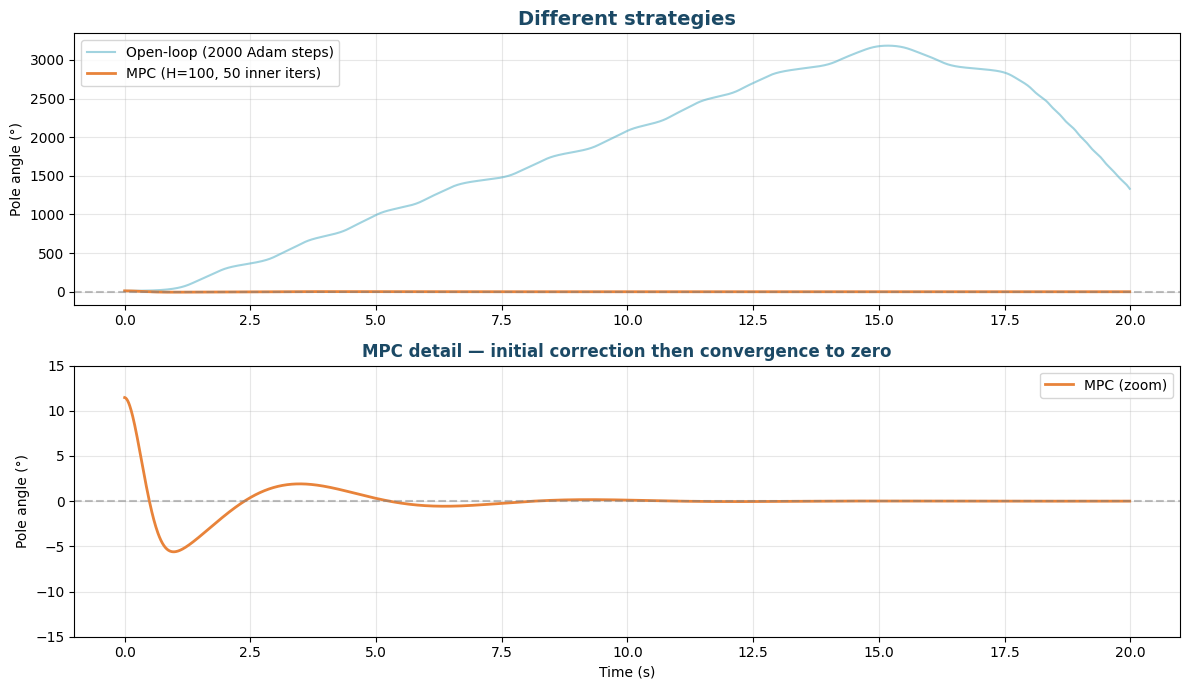

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 1]})

# Top panel: full scale — shows the brutal contrast
axes[0].plot(
    time_axis,
    np.degrees(theta_ol),
    color=PALETTE[1],
    linewidth=1.5,
    alpha=0.6,
    label=f"Open-loop ({N_OL_STEPS} Adam steps)",
)
axes[0].plot(
    time_axis,
    np.degrees(theta_arr),
    color=PALETTE[2],
    linewidth=2,
    label=f"MPC (H={H}, {N_INNER} inner iters)",
)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Pole angle (°)")
axes[0].set_title(
    "Different strategies",
    fontsize=14,
    fontweight="bold",
    color=PALETTE[0],
)
axes[0].legend(loc="upper left")

# Bottom panel: zoom on MPC — shows HOW it stabilizes
axes[1].plot(
    time_axis,
    np.degrees(theta_arr),
    color=PALETTE[2],
    linewidth=2,
    label="MPC (zoom)",
)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylim(-15, 15)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Pole angle (°)")
axes[1].set_title(
    "MPC detail — initial correction then convergence to zero",
    fontweight="bold",
    color=PALETTE[0],
)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Results

Animation of the MPC-controlled CartPole, followed by detailed state and force plots.


### Animation


Saved 200 frames at 20 fps



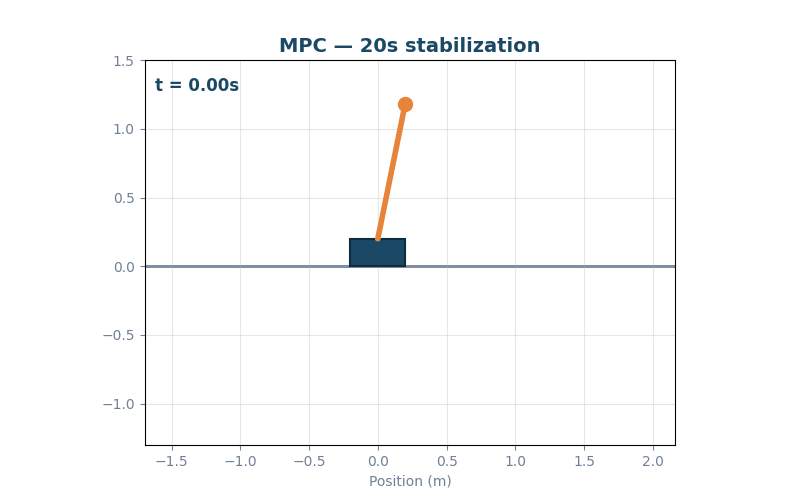

In [8]:
import base64
import shutil

from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter

POLE_LEN = 1.0
CART_W, CART_H = 0.4, 0.2
SIM_FPS = 10
GIF_FPS = 20

frame_step = max(1, int(1.0 / (SIM_FPS * DT)))
frame_indices = np.arange(0, N_STEPS, frame_step)
n_frames = len(frame_indices)

x_margin = 1.5
x_lo = x_arr[frame_indices].min() - x_margin
x_hi = x_arr[frame_indices].max() + x_margin

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_aspect("equal")
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(-1.3, 1.5)
ax.plot([x_lo, x_hi], [0, 0], color="#718096", linewidth=2, zorder=0)
ax.set_title("MPC — 20s stabilization", fontsize=14, fontweight="bold", color=PALETTE[0])
ax.set_xlabel("Position (m)", color="#718096")
ax.tick_params(colors="#718096")
ax.set_facecolor("white")
ax.grid(True, alpha=0.3)

cart = plt.Rectangle((0, 0), CART_W, CART_H, fc="#1B4965", ec="#0d2e42", lw=1.5, zorder=2)
ax.add_patch(cart)
(pole_line,) = ax.plot([], [], color=PALETTE[2], linewidth=4, solid_capstyle="round", zorder=3)
(pole_tip,) = ax.plot([], [], "o", color=PALETTE[2], markersize=10, zorder=4)
time_text = ax.text(0.02, 0.92, "", transform=ax.transAxes, fontsize=12, color=PALETTE[0], fontweight="bold")


def animate(frame_idx):
    i = frame_indices[frame_idx]
    cx = float(x_arr[i])
    th = float(theta_arr[i])
    cart.set_x(cx - CART_W / 2)
    cart.set_y(0)
    px, py = cx, CART_H
    tx = px + POLE_LEN * np.sin(th)
    ty = py + POLE_LEN * np.cos(th)
    pole_line.set_data([px, tx], [py, ty])
    pole_tip.set_data([tx], [ty])
    time_text.set_text(f"t = {i * DT:.2f}s")
    return cart, pole_line, pole_tip, time_text


anim = FuncAnimation(fig, animate, frames=n_frames, interval=1000 / GIF_FPS, blit=True)
gif_path = "cartpole_mpc.gif"
anim.save(gif_path, writer=PillowWriter(fps=GIF_FPS))
plt.close()

# Copy to docs/assets for homepage
shutil.copy2(gif_path, "../assets/cartpole_mpc.gif")
print(f"Saved {n_frames} frames at {GIF_FPS} fps")

with open(gif_path, "rb") as f:
    gif_b64 = base64.b64encode(f.read()).decode()
HTML(f'<img src="data:image/gif;base64,{gif_b64}" alt="CartPole MPC" style="width:100%">')

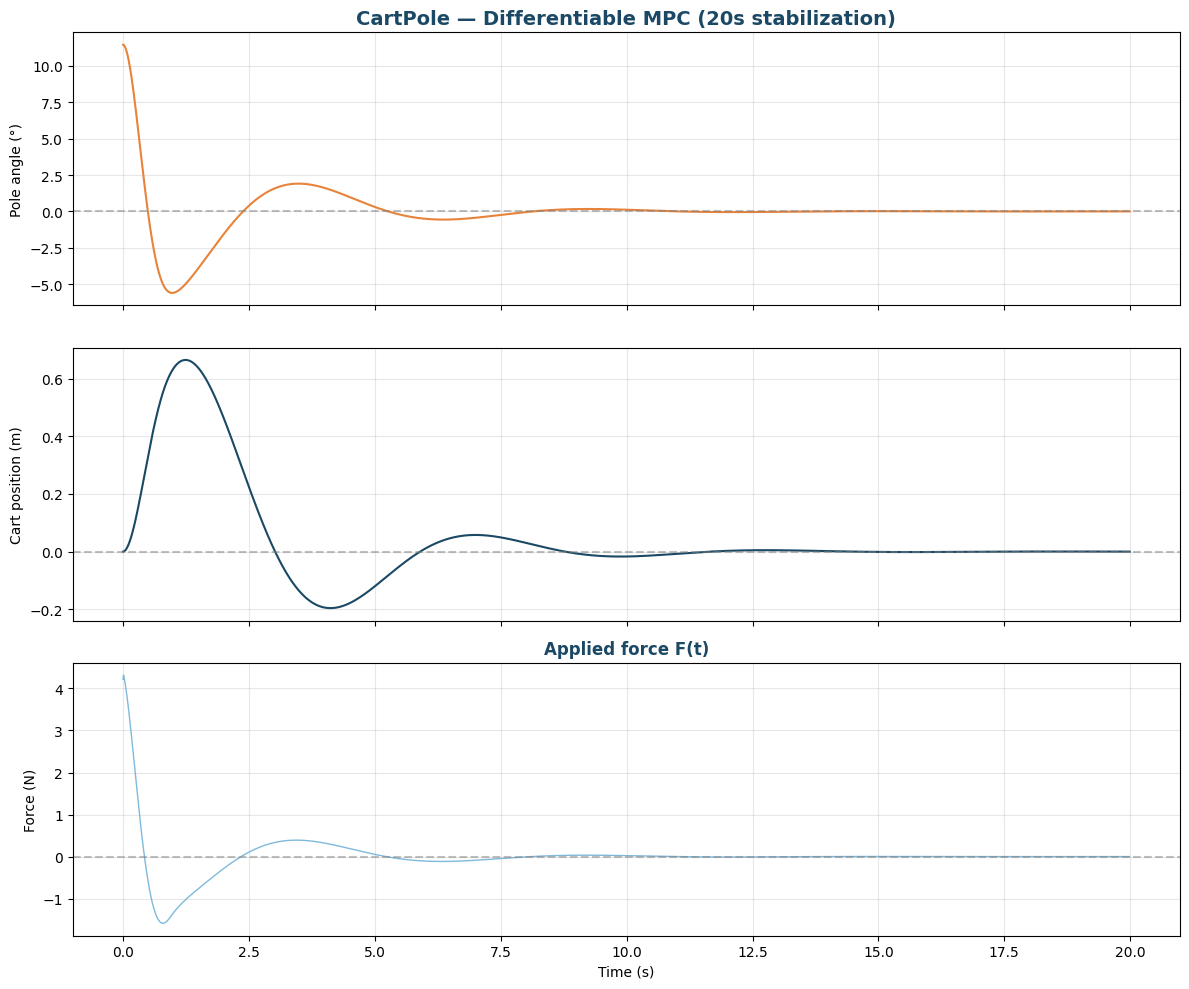

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Pole angle
axes[0].plot(time_axis, np.degrees(theta_arr), color=PALETTE[2], linewidth=1.5)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Pole angle (°)")
axes[0].set_title(
    "CartPole — Differentiable MPC (20s stabilization)",
    fontsize=14,
    fontweight="bold",
    color=PALETTE[0],
)

# Panel 2: Cart position
axes[1].plot(time_axis, x_arr, color=PALETTE[0], linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Cart position (m)")

# Panel 3: Applied force
axes[2].plot(time_axis, force_arr, color=PALETTE[3], linewidth=1.0, alpha=0.8)
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Force (N)")
axes[2].set_title("Applied force F(t)", fontweight="bold", color=PALETTE[0])

plt.tight_layout()
plt.show()

## Summary

|                     | Open-loop (open-loop)                        | MPC (this notebook)                          |
| ------------------- | ------------------------------------------- | -------------------------------------------- |
| **Horizon**         | Full trajectory (2000 steps)                | Sliding window (**100 steps**)               |
| **Gradient length** | 2000 steps — degrades on longer simulations | Always **100 steps** — bounded and stable    |
| **Duration**        | ~2s (longer horizons fail)                  | **20s** demonstrated (no limit)              |
| **Feedback**        | None (pre-computed plan)                    | Re-plans at every timestep                   |
| **Speed**           | N/A                                         | **0.22 ms/step** — 45× faster than real-time |

### Why it works

MPC solves the **vanishing gradient problem** mechanically: backpropagation is limited to H=100 steps instead of the full 2000-step trajectory. The gradient stays short, stable, and informative — a 20× reduction in chain length.

**Warm starting** is the other key ingredient. At each MPC step, the action buffer is shifted by one position: the previous plan is already nearly optimal for the new state. This reduces inner optimization from 500+ cold-start iterations (open-loop) to just 50 — a principle used in industrial MPC since the 1970s, now applied to nonlinear physics via JAX's automatic differentiation.

### No engine changes needed

This entire notebook uses only existing SeapoPym primitives:

- `build_step_fn(model)` → the single-step function
- `lax.scan(step_fn, ...)` → differentiable rollout over H steps
- `jax.grad` → per-timestep force gradients

The MPC controller is **pure composition** — SeapoPym's DAG + step_fn architecture is modular enough to support closed-loop planning without any framework modifications.

### Next steps

The MPC framework opens several extensions:

- **External perturbations** — apply an unexpected force mid-simulation; the MPC re-plans and adapts
- **Noisy observations** — add Gaussian noise to the observed state; test robustness
- **Learned world models** — replace the mechanistic physics with a neural network predictor; the same `rollout` → `grad` → `optimize` pattern applies

**Next:** [LMTL Marine Ecosystem — No Transport](../04_lmtl_no_transport/)